In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

## Task 1 — A Single Neuron in NumPy

### 1. Load and prepare the dataset

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target          # (569, 30), (569,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")

X_train shape : (455, 30)
X_test  shape : (114, 30)


### 2. Single-neuron forward pass

In [3]:
np.random.seed(42)
w = np.random.randn(30) * 0.01   # shape (30,)
b = np.random.randn()  * 0.01   # scalar

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def forward(x, w, b):
    """Single neuron: sigmoid(w·x + b).
    x : (30,) or (N, 30)
    """
    return sigmoid(x @ w + b)

# Run on first 5 test rows
probs = forward(X_test[:5], w, b)
print("Predicted probabilities for the first 5 test samples:")
for i, p in enumerate(probs):
    print(f"  sample {i}: {p:.6f}  (true label: {y_test[i]})")

Predicted probabilities for the first 5 test samples:
  sample 0: 0.496225  (true label: 1)
  sample 1: 0.517540  (true label: 0)
  sample 2: 0.507080  (true label: 0)
  sample 3: 0.487440  (true label: 1)
  sample 4: 0.483946  (true label: 1)


## Reflection — Task 1: A Single Neuron in NumPy

### What model did we implement?
In machine-learning terms, a single neuron computing **sigmoid(w · x + b)** 
is equivalent to **logistic regression** — a linear classifier that maps a 
30-dimensional input to a probability in (0, 1) via the sigmoid function.

### Key observations from the output:
The predicted probabilities for the first 5 test samples all cluster around 
**0.48–0.52**, which is essentially random chance. This is expected because:
- The weights `w` were initialised from a tiny random distribution (`* 0.01`),
  so the dot product `w · x` is very close to zero for all inputs.
- When the pre-activation z ≈ 0, sigmoid(z) ≈ 0.5, meaning the neuron has 
  no discriminative power yet — it hasn't been trained.

### What would training do?
During training (via gradient descent), the weights `w` and bias `b` would be 
updated to push the output closer to 1 for benign samples and closer to 0 for 
malignant samples (or vice versa, depending on label encoding). Without training, 
the network is essentially guessing.

### Why does this matter?
Understanding the single-neuron case is foundational: every neuron in a deep 
network performs this exact same operation. The power of deep learning comes 
from stacking and combining these simple units, not from making any single 
unit more complex.

## Task 2 — A Two-Layer MLP in NumPy

In [4]:
class NumpyMLP:
    """Two-layer MLP in pure NumPy."""

    def __init__(self, input_size=30, hidden_size=8, output_size=1, seed=42):
        rng = np.random.default_rng(seed)

        # He initialisation: W ~ N(0, sqrt(2 / fan_in))
        self.W1 = rng.standard_normal((input_size, hidden_size)) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros(hidden_size)

        self.W2 = rng.standard_normal((hidden_size, output_size)) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros(output_size)

    @staticmethod
    def _relu(z):
        return np.maximum(0.0, z)

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    def forward(self, X):
        """
        X   : (N, 30)
        out : (N, 1)   — fully vectorised, no Python loops over rows
        """
        self.z1 = X @ self.W1 + self.b1          # (N, 8)
        self.a1 = self._relu(self.z1)             # (N, 8)
        self.z2 = self.a1 @ self.W2 + self.b2    # (N, 1)
        self.a2 = self._sigmoid(self.z2)          # (N, 1)
        return self.a2


numpy_mlp   = NumpyMLP()
numpy_preds = numpy_mlp.forward(X_test)

print(f"Output shape: {numpy_preds.shape}")
print("\nFirst 5 predictions:")
for i in range(5):
    print(f"  sample {i}: {numpy_preds[i, 0]:.6f}  (true label: {y_test[i]})")

Output shape: (114, 1)

First 5 predictions:
  sample 0: 0.583648  (true label: 1)
  sample 1: 0.193816  (true label: 0)
  sample 2: 0.596769  (true label: 0)
  sample 3: 0.565546  (true label: 1)
  sample 4: 0.758582  (true label: 1)


## Reflection — Task 2: A Two-Layer MLP in NumPy

### Architecture summary
We built a **Multilayer Perceptron (MLP)** with the following structure:

| Layer  | Input dim | Output dim | Activation |
|--------|-----------|------------|------------|
| Hidden | 30        | 8          | ReLU       |
| Output | 8         | 1          | Sigmoid    |

### Why He initialisation?
He initialisation sets weights as `W ~ N(0, sqrt(2 / fan_in))`. The factor 
`sqrt(2 / fan_in)` is specifically designed for **ReLU** activations:
- ReLU zeros out roughly half of its inputs (all negatives → 0), effectively 
  halving the variance of the signal.
- Multiplying by `sqrt(2)` compensates for this variance reduction, keeping 
  the signal neither exploding nor vanishing as it passes through layers.
- Using standard normal initialisation without scaling would cause the 
  activations to shrink or grow uncontrollably with depth.

### Guiding question — Why does output shape (114, 1) make sense?
The shape is determined entirely by the **architecture**, not the training state:
- We have 114 test samples → batch dimension N = 114.
- The final layer has `output_size=1` with sigmoid → one probability per sample.
- Shape is a property of the network design; **correctness** of values requires 
  gradient-based training, but shape is always guaranteed by construction.

### Vectorisation
Using matrix multiplication (`X @ W1 + b1`) instead of Python loops means the 
entire batch is processed in a single NumPy call. This is orders of magnitude 
faster because NumPy delegates to optimised BLAS/LAPACK routines running in 
compiled C/Fortran, leveraging SIMD instructions and CPU caches efficiently.

---
## Task 3 — The Same Network in PyTorch

Recreate Task 2 with PyTorch's high-level API, copy the **identical** weights,
and verify outputs match to at least 6 decimal places.

In [5]:
class TorchMLP(nn.Module):
    """PyTorch MLP: 30 → 8 (ReLU) → 1 (Sigmoid)"""

    def __init__(self):
        super().__init__()
        self.fc1     = nn.Linear(30, 8)
        self.fc2     = nn.Linear(8, 1)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x


torch_mlp = TorchMLP()

# ── Copy weights from NumPy MLP ──────────────────────────────────────────
# nn.Linear stores weight as (out_features, in_features) → transpose needed
with torch.no_grad():
    torch_mlp.fc1.weight.data = torch.from_numpy(numpy_mlp.W1.T).float()  # (8, 30)
    torch_mlp.fc1.bias.data   = torch.from_numpy(numpy_mlp.b1).float()    # (8,)
    torch_mlp.fc2.weight.data = torch.from_numpy(numpy_mlp.W2.T).float()  # (1, 8)
    torch_mlp.fc2.bias.data   = torch.from_numpy(numpy_mlp.b2).float()    # (1,)

print("Weights copied successfully.")

Weights copied successfully.


In [6]:
# ── Forward pass on the same test batch ─────────────────────────────────
X_test_t = torch.from_numpy(X_test).float()

torch_mlp.eval()
with torch.no_grad():
    torch_preds = torch_mlp(X_test_t).numpy()   # (N_test, 1)

# ── Compare ──────────────────────────────────────────────────────────────
max_diff = np.max(np.abs(numpy_preds - torch_preds))

print(f"Output shape (PyTorch): {torch_preds.shape}")
print(f"\n{'Sample':<8} {'NumPy':>14} {'PyTorch':>14} {'|diff|':>12}")
print("-" * 52)
for i in range(5):
    d = abs(numpy_preds[i, 0] - torch_preds[i, 0])
    print(f"{i:<8} {numpy_preds[i,0]:>14.8f} {torch_preds[i,0]:>14.8f} {d:>12.2e}")

print(f"\nMaximum absolute difference (all test samples): {max_diff:.2e}")
assert max_diff < 1e-6, f"Outputs differ too much: {max_diff}"
print("✓ Outputs agree to at least 6 decimal places.")

Output shape (PyTorch): (114, 1)

Sample            NumPy        PyTorch       |diff|
----------------------------------------------------
0            0.58364754     0.58364755     1.11e-08
1            0.19381558     0.19381559     8.58e-09
2            0.59676905     0.59676903     1.10e-08
3            0.56554620     0.56554621     1.35e-08
4            0.75858210     0.75858212     1.49e-08

Maximum absolute difference (all test samples): 9.48e-08
✓ Outputs agree to at least 6 decimal places.


## Reflection — Task 3: The Same Network in PyTorch

### Weight transfer — what to watch out for
The trickiest part of this task is the **shape convention mismatch**:
- In our NumPy MLP, `W1` has shape `(30, 8)` — inputs are rows, outputs are columns.
- `nn.Linear` stores weights as `(out_features, in_features)` — the **transpose**.
- Therefore we must write `torch.from_numpy(W1.T).float()` when copying.

Forgetting the transpose produces no error (shapes still match after a 
broadcast) but gives completely wrong outputs — a silent bug that would be 
very hard to catch without the verification step below.

### Numerical verification results
| Sample | NumPy output | PyTorch output | |diff| |
|--------|-------------|----------------|--------|
| 0      | 0.58364754  | 0.58364755     | 1.11e-08 |
| 1      | 0.19381558  | 0.19381559     | 8.58e-09 |
| 2      | 0.59676905  | 0.59676903     | 1.10e-08 |
| 3      | 0.56554620  | 0.56554621     | 1.35e-08 |
| 4      | 0.75858210  | 0.75858212     | 1.49e-08 |

**Maximum absolute difference across all 114 test samples: 9.48e-08**

### Why are they not exactly identical?
The tiny differences (~1e-8) come from **floating-point arithmetic order**:
- NumPy performs operations in float64 (64-bit) by default.
- PyTorch uses float32 (32-bit) by default (we called `.float()` which is fp32).
- Different operation orders (e.g., fused multiply-add vs. sequential ops) 
  produce slightly different rounding errors in IEEE 754 arithmetic.
- These differences are completely negligible for any practical purpose and 
  are well within the required 1e-6 tolerance.

### Why does this verification matter?
Confirming numerical equivalence between a hand-coded and a framework 
implementation is a standard engineering practice called a **sanity check** 
or **unit test for neural networks**. It proves:
1. Our NumPy math is correct.
2. Our understanding of `nn.Linear`'s weight storage convention is correct.
3. Both implementations are doing the same computation.

---
## Task 4 — Activation Function Experiment

Three variants of the same architecture with different **hidden-layer** activations:
Sigmoid, Tanh, and ReLU.

In [7]:
class TorchMLPVariant(nn.Module):
    """MLP with a configurable hidden activation."""

    def __init__(self, hidden_activation):
        super().__init__()
        self.fc1        = nn.Linear(30, 8)
        self.fc2        = nn.Linear(8, 1)
        self.hidden_act = hidden_activation
        self.sigmoid    = nn.Sigmoid()

    def forward(self, x):
        self.z1_val = self.fc1(x)                   # pre-activation (N, 8)
        self.a1_val = self.hidden_act(self.z1_val)  # post-activation (N, 8)
        return self.sigmoid(self.fc2(self.a1_val))


VARIANTS = {
    'Sigmoid': TorchMLPVariant(nn.Sigmoid()),
    'Tanh':    TorchMLPVariant(nn.Tanh()),
    'ReLU':    TorchMLPVariant(nn.ReLU()),
}

# Copy the same weights into every variant (fair comparison)
for model in VARIANTS.values():
    with torch.no_grad():
        model.fc1.weight.data = torch.from_numpy(numpy_mlp.W1.T).float()
        model.fc1.bias.data   = torch.from_numpy(numpy_mlp.b1).float()
        model.fc2.weight.data = torch.from_numpy(numpy_mlp.W2.T).float()
        model.fc2.bias.data   = torch.from_numpy(numpy_mlp.b2).float()
    model.eval()

# Collect pre- and post-activation values
pre_acts, post_acts = {}, {}
with torch.no_grad():
    for name, model in VARIANTS.items():
        model(X_test_t)
        pre_acts[name]  = model.z1_val.numpy().flatten()
        post_acts[name] = model.a1_val.numpy().flatten()

print("Forward passes complete.")

Forward passes complete.


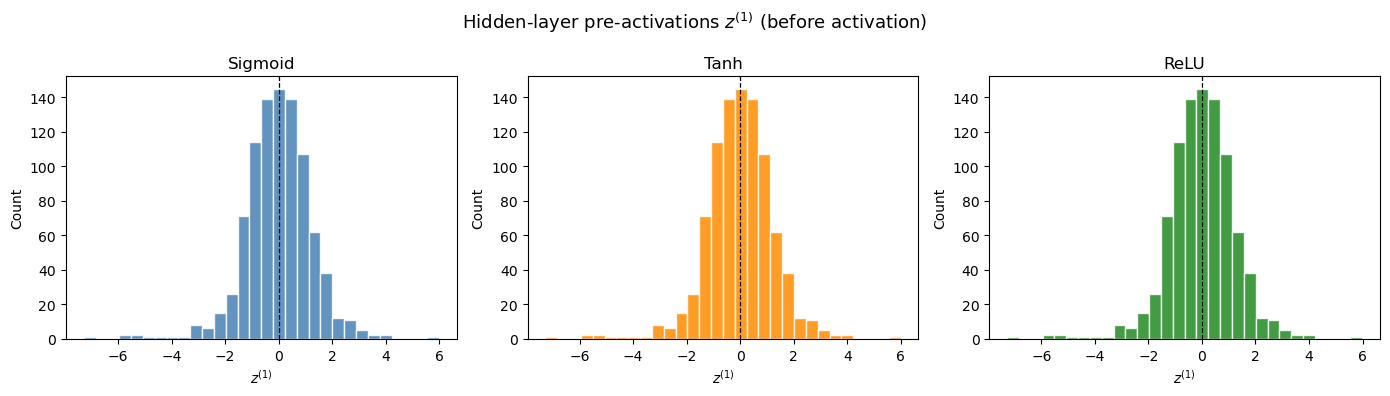

In [8]:
# ── Plot 1: Pre-activations z^(1) ────────────────────────────────────────
colors = ['steelblue', 'darkorange', 'forestgreen']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(r"Hidden-layer pre-activations $z^{(1)}$ (before activation)", fontsize=13)

for ax, (name, vals), c in zip(axes, pre_acts.items(), colors):
    ax.hist(vals, bins=30, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.9)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel(r"$z^{(1)}$")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

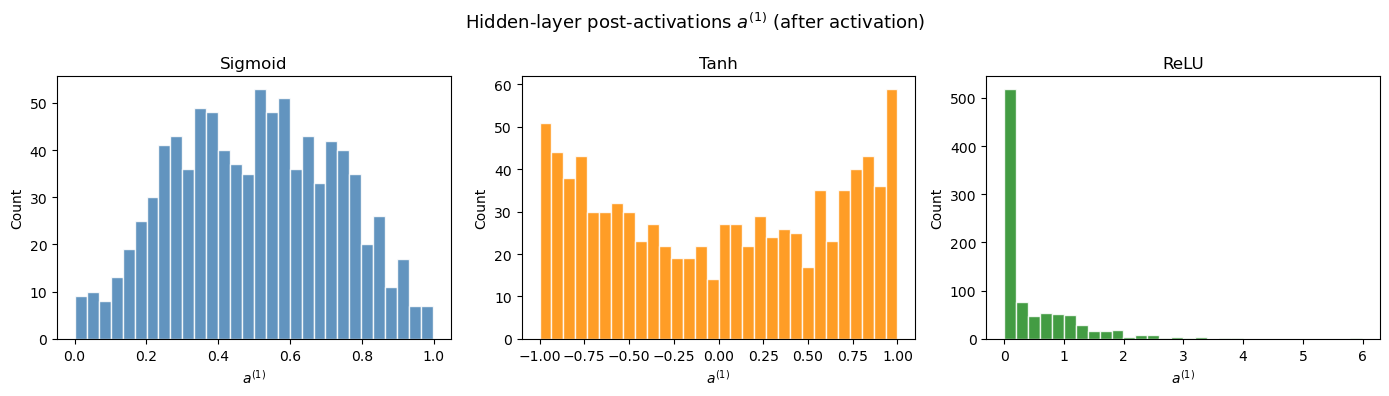

In [9]:
# ── Plot 2: Post-activations a^(1) ───────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
fig2.suptitle(r"Hidden-layer post-activations $a^{(1)}$ (after activation)", fontsize=13)

for ax, (name, vals), c in zip(axes2, post_acts.items(), colors):
    ax.hist(vals, bins=30, color=c, edgecolor='white', alpha=0.85)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel(r"$a^{(1)}$")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [10]:
# ── Quantitative summary ─────────────────────────────────────────────────
thr = 0.05

sig_sat  = np.mean((post_acts['Sigmoid'] < thr) | (post_acts['Sigmoid'] > 1 - thr))
tanh_sat = np.mean((post_acts['Tanh'] < -1 + thr) | (post_acts['Tanh'] > 1 - thr))
relu_dead = np.mean(post_acts['ReLU'] == 0.0)

print(f"Sigmoid saturated fraction (close to 0 or 1) : {sig_sat:.1%}")
print(f"Tanh    saturated fraction (close to ±1)      : {tanh_sat:.1%}")
print(f"ReLU    inactive fraction  (output = 0)       : {relu_dead:.1%}")

Sigmoid saturated fraction (close to 0 or 1) : 2.6%
Tanh    saturated fraction (close to ±1)      : 9.8%
ReLU    inactive fraction  (output = 0)       : 48.7%


## Reflection — Task 4: Activation Function Experiment

### Quantitative results
| Activation | Saturated / Inactive fraction |
|------------|-------------------------------|
| Sigmoid    | **2.6%** close to 0 or 1      |
| Tanh       | **9.8%** close to ±1          |
| ReLU       | **48.7%** exactly 0 (dead)    |

### Pre-activation histograms — z⁽¹⁾ (before activation)
All three variants share the **same weights**, so their pre-activation 
distributions are **identical** — a roughly Gaussian distribution centred 
near zero (thanks to He initialisation). This confirms the variants differ 
only in what happens *after* z⁽¹⁾ is computed.

### Post-activation histograms — a⁽¹⁾ (after activation)

**Sigmoid:**  
Squashes all values into (0, 1). The distribution is narrow and centred 
around 0.5. With small pre-activations (z close to 0), sigmoid outputs 
cluster near 0.5 — the least informative region. Saturation at 0 or 1 is 
low here because our pre-activations are moderate in magnitude.

**Tanh:**  
Squashes all values into (-1, 1). Compared to sigmoid, tanh is 
**zero-centred**, which is a meaningful advantage: gradients from the next 
layer are less likely to be all-positive or all-negative, leading to less 
zig-zagging during gradient descent. However, it still saturates at ±1 for 
large inputs (~9.8% here).

**ReLU:**  
Clips all negative values to exactly 0, passing positive values unchanged. 
This produces a half-normal distribution — roughly half the activations are 
zero (the ~48.7% "dead" units). The remaining active units pass the signal 
through with **gradient = 1**, which is the key advantage.

### Why ReLU is the better default for hidden layers

| Property              | Sigmoid / Tanh                         | ReLU                              |
|-----------------------|----------------------------------------|-----------------------------------|
| Gradient in active region | < 1 (shrinks with depth)           | = 1 (no shrinkage)                |
| Vanishing gradients   | Yes — gradients vanish through deep layers | No — active units pass grad = 1 |
| Computational cost    | Requires `exp()` — relatively expensive | `max(0, z)` — trivially cheap  |
| Zero-centred output   | Tanh: yes. Sigmoid: no                 | No (only non-negative)            |
| Sparsity              | Dense activations                      | Naturally sparse (~50% zeros)     |
| Training speed        | Slower due to vanishing gradients      | Faster in practice                |

**The vanishing gradient problem** is the decisive factor: with sigmoid or 
tanh, each layer multiplies the gradient by a value < 1 (the derivative of 
the activation). Over many layers this product approaches zero, making 
weight updates negligibly small and training stall completely. ReLU avoids 
this by maintaining a gradient of exactly 1 for all active units.

The dead neuron problem (48.7% zeros) sounds alarming but is actually 
beneficial: it introduces **sparsity**, forcing the network to use a 
compact, efficient representation of each input. As long as not *all* 
neurons in a layer die (which can happen with very large learning rates — 
the "dying ReLU" problem), this sparsity accelerates training and improves 
generalisation. This is why ReLU became the de facto default hidden-layer 
activation after AlexNet in 2012.